Dataset Shape: (768, 9)

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

--- Statistical Summary ---
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean    

C:\Users\dhany\AppData\Local\Temp\ipykernel_11508\3701189110.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Outcome', data=df, palette="viridis")


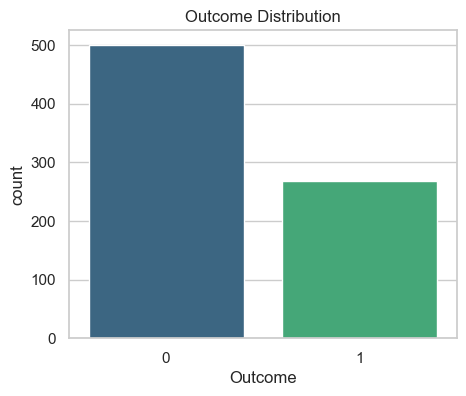


Class Distribution (%):
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


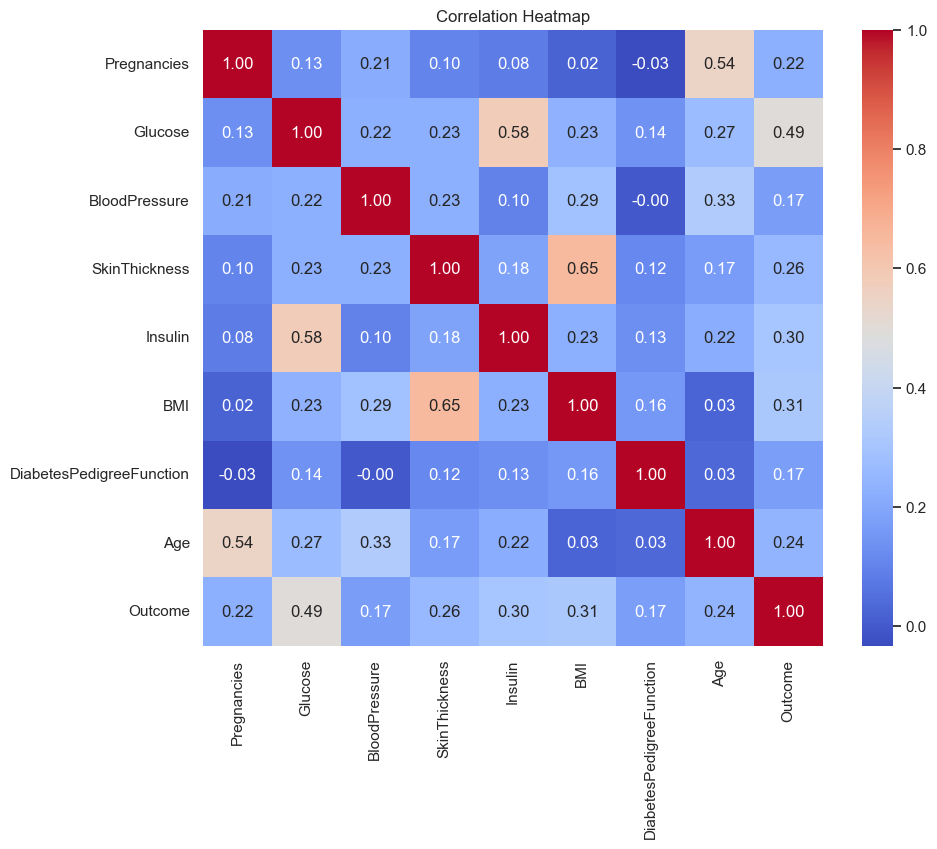

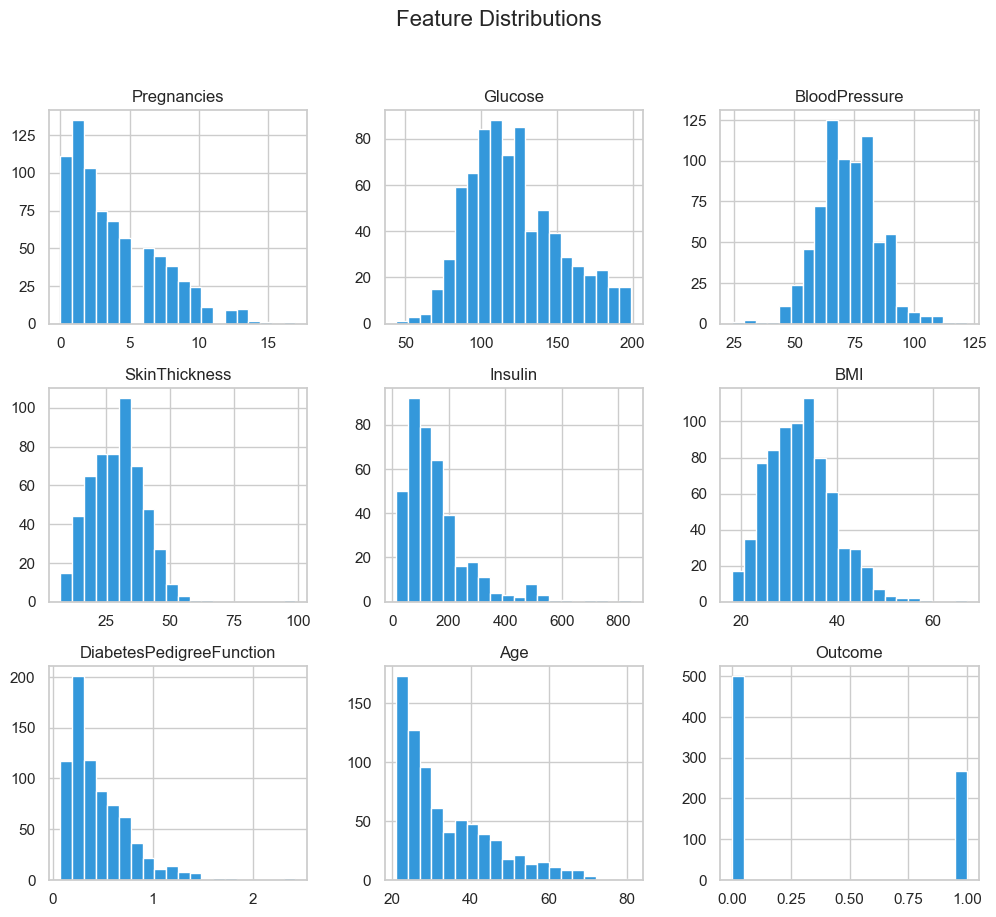

C:\Users\dhany\AppData\Local\Temp\ipykernel_11508\3701189110.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y=col, data=df, palette="Set2")


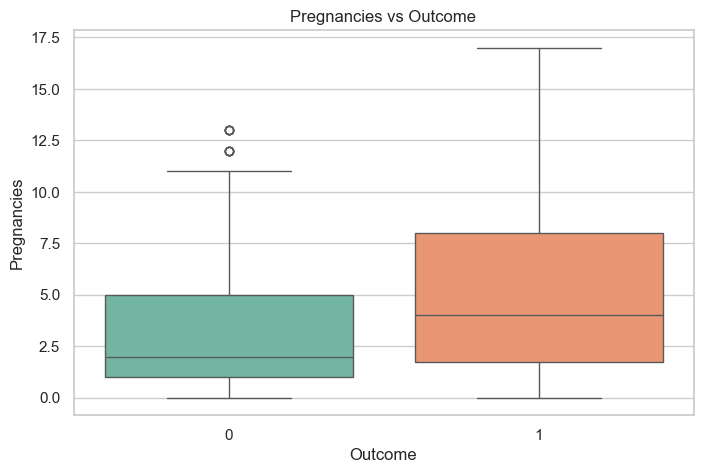

C:\Users\dhany\AppData\Local\Temp\ipykernel_11508\3701189110.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y=col, data=df, palette="Set2")


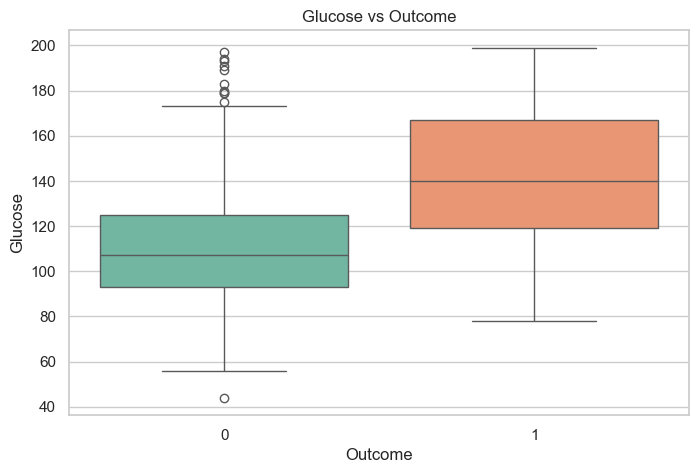

C:\Users\dhany\AppData\Local\Temp\ipykernel_11508\3701189110.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y=col, data=df, palette="Set2")


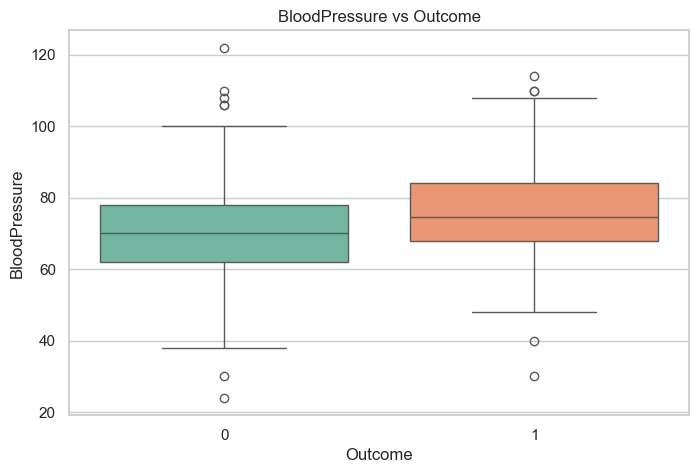

C:\Users\dhany\AppData\Local\Temp\ipykernel_11508\3701189110.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y=col, data=df, palette="Set2")


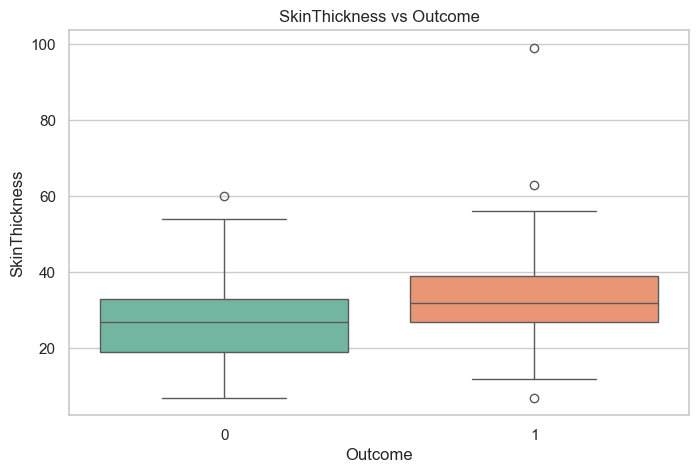

C:\Users\dhany\AppData\Local\Temp\ipykernel_11508\3701189110.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y=col, data=df, palette="Set2")


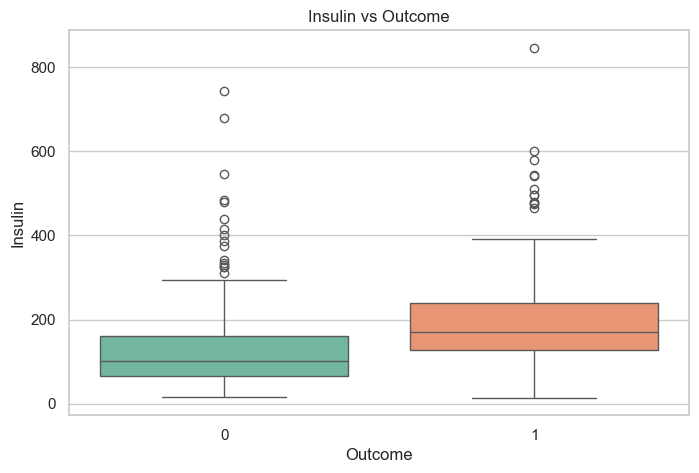

C:\Users\dhany\AppData\Local\Temp\ipykernel_11508\3701189110.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y=col, data=df, palette="Set2")


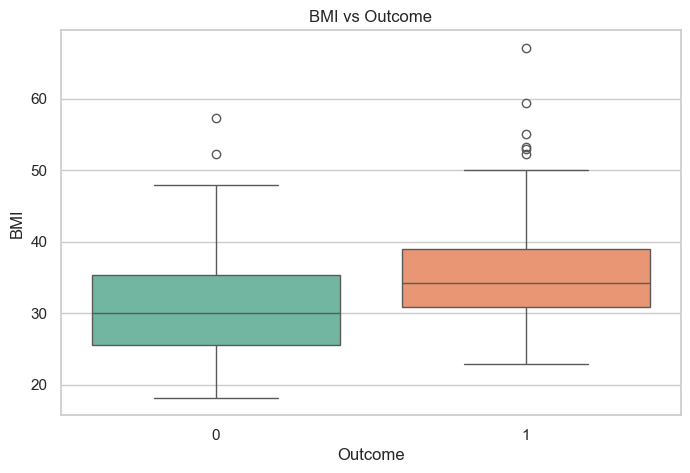

C:\Users\dhany\AppData\Local\Temp\ipykernel_11508\3701189110.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y=col, data=df, palette="Set2")


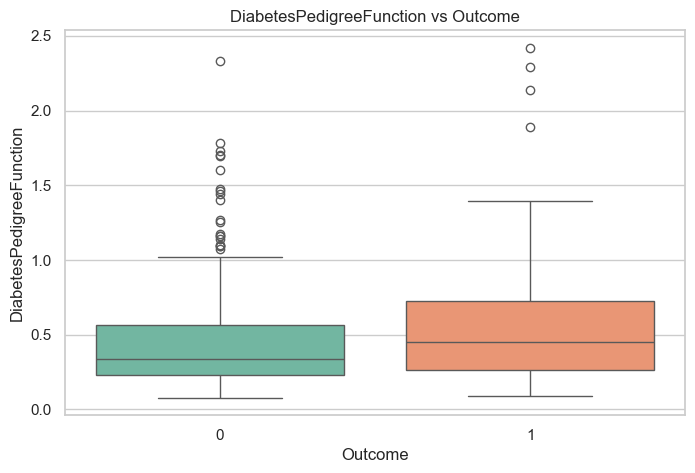

C:\Users\dhany\AppData\Local\Temp\ipykernel_11508\3701189110.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y=col, data=df, palette="Set2")


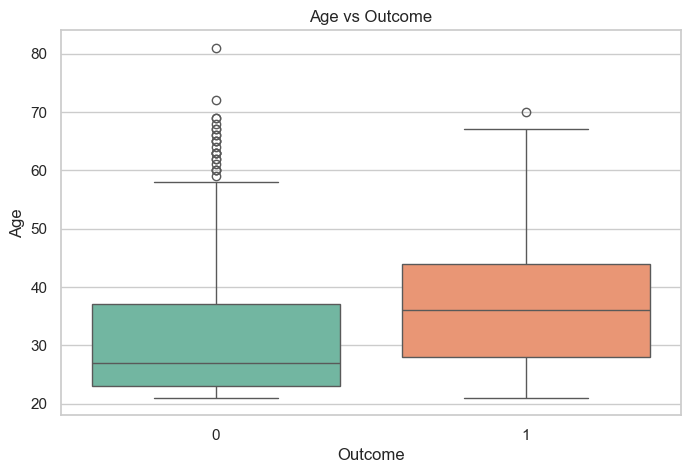

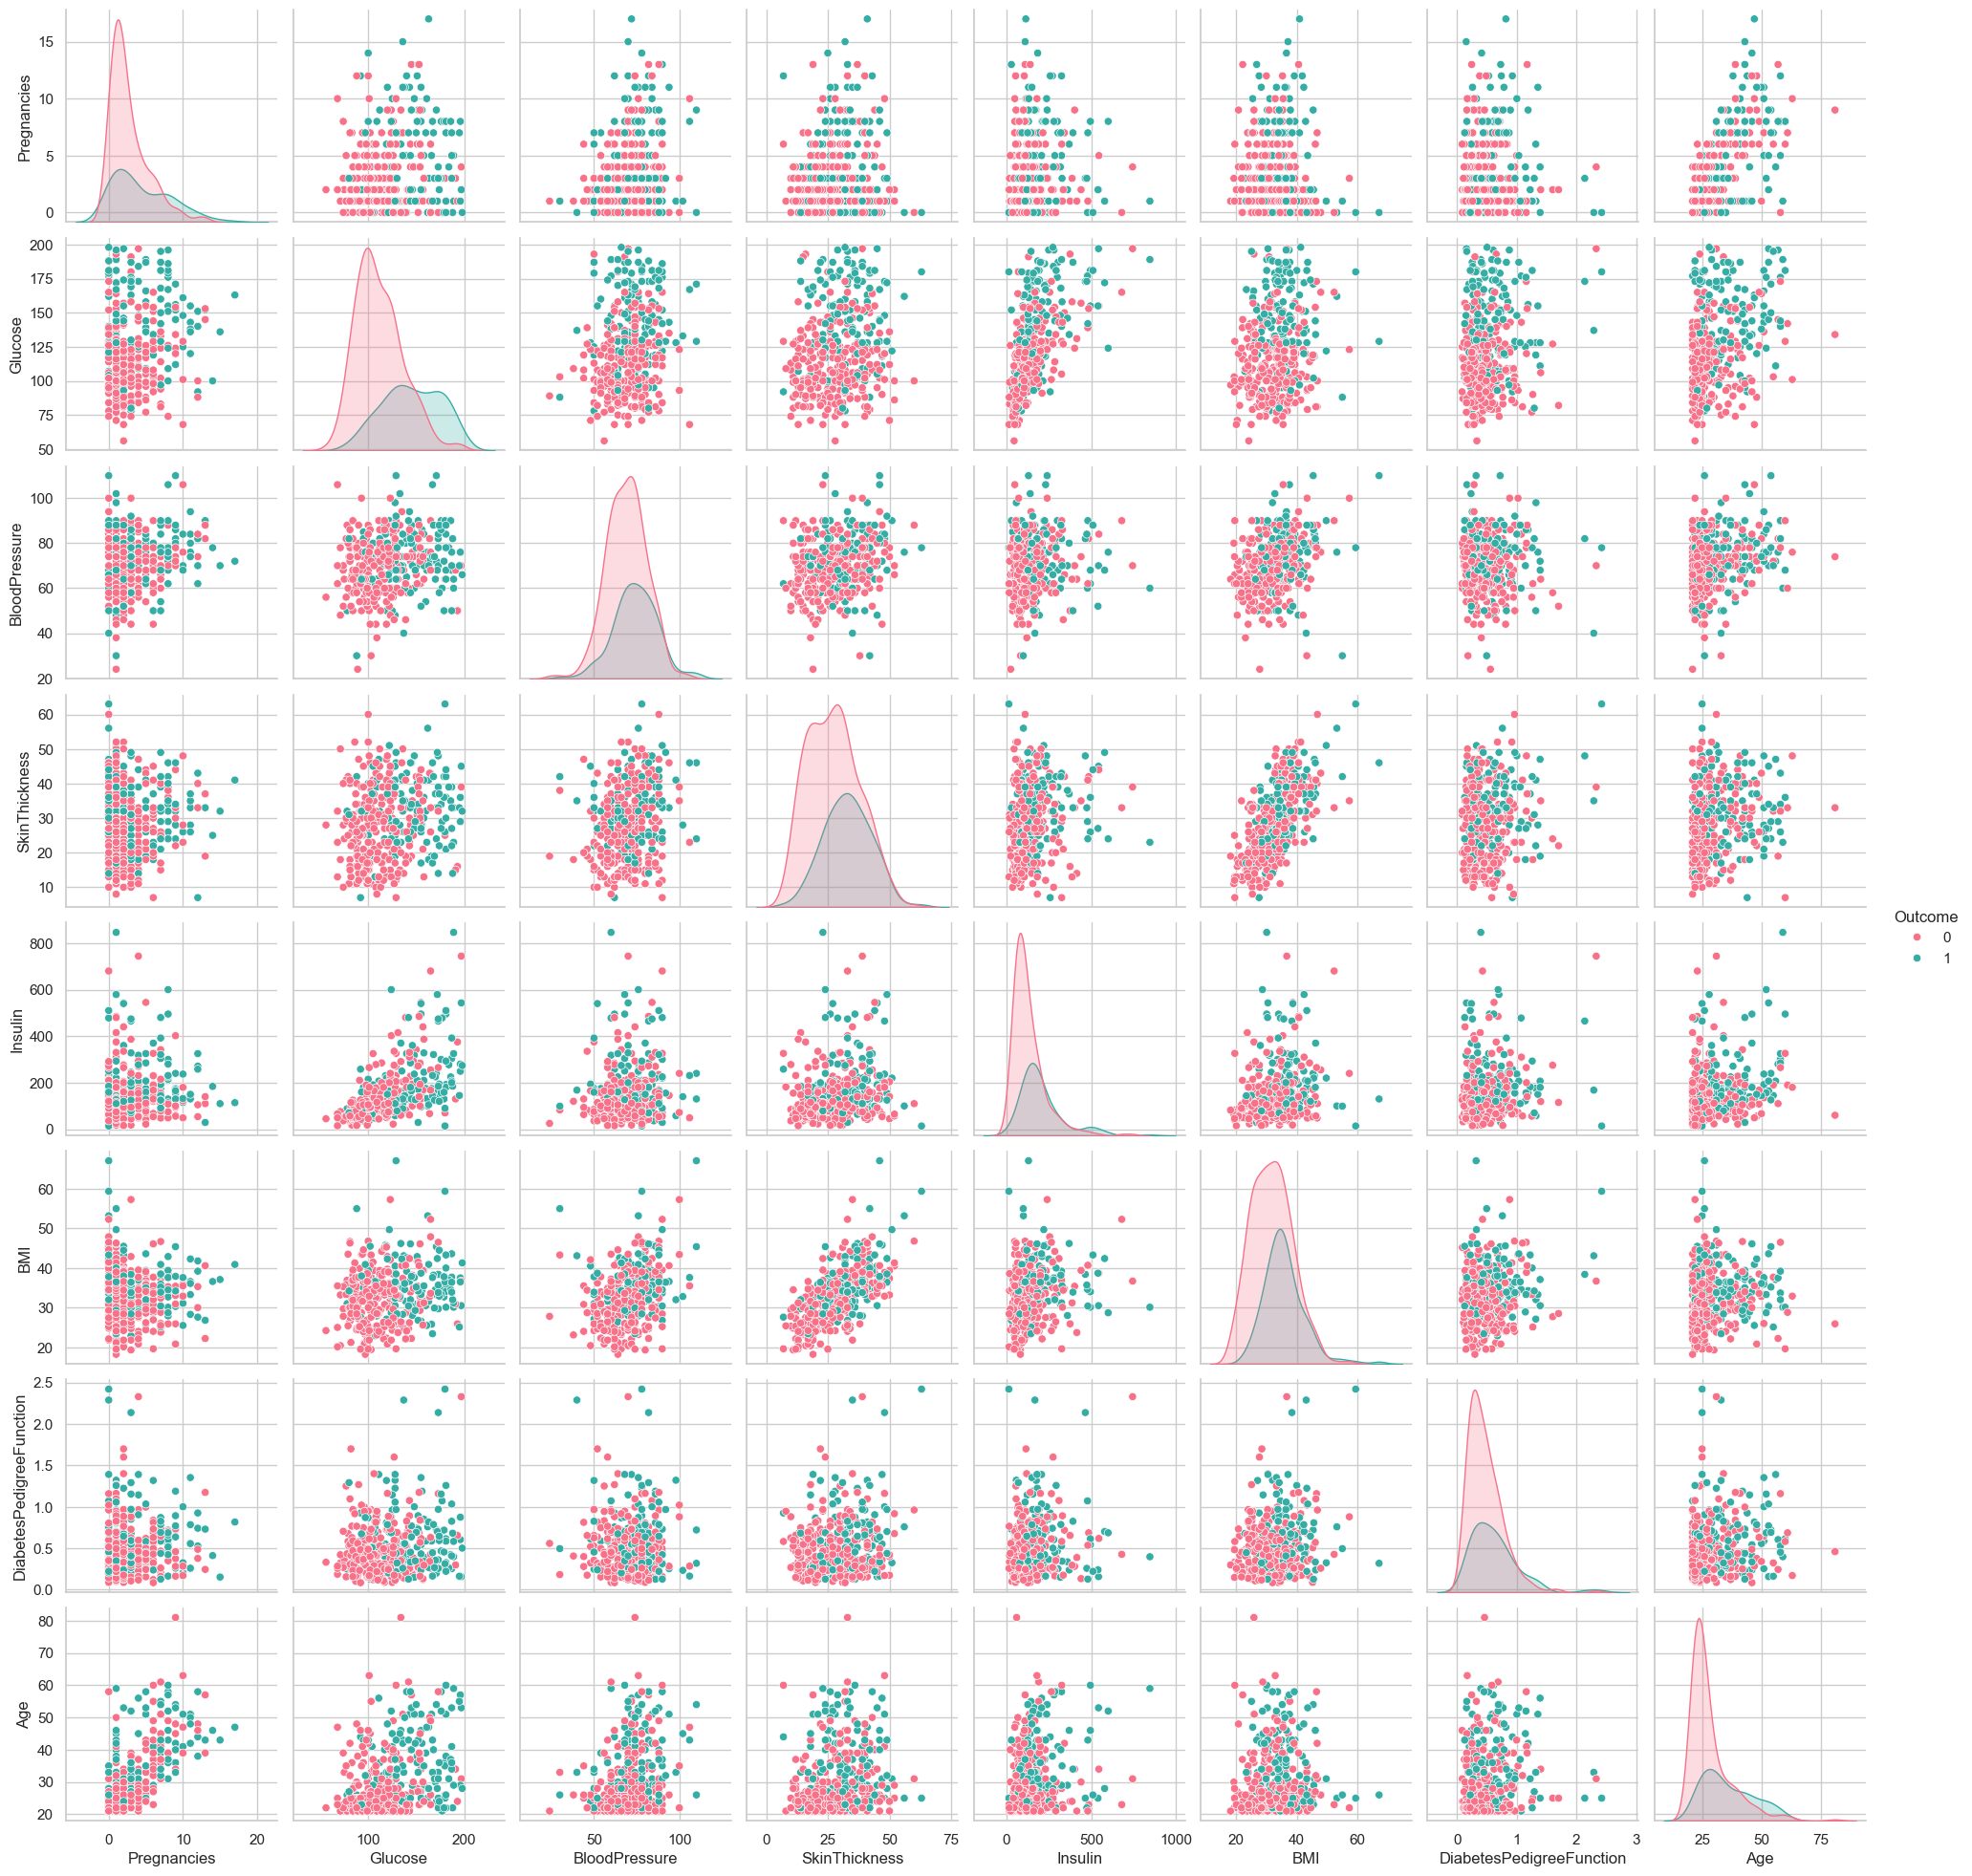

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visuals
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# =============================
# 2. Load Dataset
# =============================
df = pd.read_csv("diabetes.csv")
print("Dataset Shape:", df.shape)
df.head()

print("\n--- Dataset Info ---")
print(df.info())

print("\n--- Statistical Summary ---")
print(df.describe())

zero_columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in zero_columns:
    zero_count = (df[col] == 0).sum()
    print(f"{col}: {zero_count} zeros")

# Replace zeros with NaN for visualization of missingness
df[zero_columns] = df[zero_columns].replace(0, np.nan)

print("\nMissing values per column:")
print(df.isnull().sum())


plt.figure(figsize=(5,4))
sns.countplot(x='Outcome', data=df, palette="viridis")
plt.title("Outcome Distribution")
plt.show()

print("\nClass Distribution (%):")
print(df['Outcome'].value_counts(normalize=True) * 100)

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


df.hist(bins=20, figsize=(12,10), color="#3498db")
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()

for col in df.columns[:-1]:  # exclude Outcome
    plt.figure()
    sns.boxplot(x='Outcome', y=col, data=df, palette="Set2")
    plt.title(f"{col} vs Outcome")
    plt.show()


sns.pairplot(df.dropna(), hue="Outcome", palette="husl")
plt.show()


In [ ]:
"""
preprocess_diabetes.py — fixed version

Preprocessing pipeline for Pima Indians Diabetes dataset:
- Replaces 0 values with NaN in certain columns
- Imputes missing values
- Scales features
- Splits into train/test
- Optionally applies SMOTE
- Saves imputer & scaler as artifacts
"""

import os
import joblib
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# ---------- CONFIG ----------
DATA_PATH = r"C:\Users\dhany\CODING ( END OF ME! )\FDS PROJECT\diabetes.csv"  # Path to your dataset
TARGET_COL = "Outcome"
ZERO_AS_NAN_COLS = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
IMPUTE_STRATEGY = "median"
TEST_SIZE = 0.2
RANDOM_STATE = 42
APPLY_SMOTE = True
ARTIFACT_DIR = "artifacts"
# ----------------------------


def load_data(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    return df


def mark_zeros_as_nan(df: pd.DataFrame, cols: list) -> pd.DataFrame:
    df = df.copy()
    for c in cols:
        df[c] = df[c].replace(0, np.nan)
    return df


def impute_missing_values(df: pd.DataFrame, cols: list, strategy: str = "median"):
    imputer = SimpleImputer(strategy=strategy)
    df = df.copy()
    df[cols] = imputer.fit_transform(df[cols])
    return df, imputer


def scale_features(X_train: pd.DataFrame, X_test: pd.DataFrame):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)
    return X_train_scaled, X_test_scaled, scaler


def train_test_split_stratified(df: pd.DataFrame, target_col: str, test_size: float, random_state: int):
    X = df.drop(columns=[target_col])
    y = df[target_col]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    return X_train, X_test, y_train, y_test


def apply_smote(X_train: pd.DataFrame, y_train: pd.Series, random_state: int):
    sm = SMOTE(random_state=random_state)
    X_res, y_res = sm.fit_resample(X_train, y_train)
    X_res = pd.DataFrame(X_res, columns=X_train.columns)
    y_res = pd.Series(y_res, name=y_train.name)
    return X_res, y_res


def ensure_dir(path: str):
    os.makedirs(path, exist_ok=True)


def save_artifacts(imputer, scaler, artifact_dir="artifacts"):
    ensure_dir(artifact_dir)
    joblib.dump(imputer, os.path.join(artifact_dir, "imputer.joblib"))
    joblib.dump(scaler, os.path.join(artifact_dir, "scaler.joblib"))
    print(f"✅ Saved artifacts to {artifact_dir}/")


def preprocess_pipeline(
    data_path=DATA_PATH,
    zero_cols=ZERO_AS_NAN_COLS,
    target_col=TARGET_COL,
    impute_strategy=IMPUTE_STRATEGY,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    apply_smote_flag=APPLY_SMOTE,
    artifact_dir=ARTIFACT_DIR
):
    # ✅ Load dataset first (this was missing before!)
    df = load_data(data_path)
    print("Loaded dataset:", df.shape)

    # Replace zeros with NaN
    df = mark_zeros_as_nan(df, zero_cols)
    print("Replaced zeros with NaN in:", zero_cols)
    print("Missing values before imputation:\n", df.isnull().sum())

    # Impute missing values
    df_imputed, imputer = impute_missing_values(df, zero_cols, strategy=impute_strategy)
    print("Missing values after imputation:\n", df_imputed.isnull().sum())

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split_stratified(df_imputed, target_col, test_size, random_state)
    print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

    # Scale features
    X_train_scaled, X_test_scaled, scaler = scale_features(X_train, X_test)
    print("Feature scaling done.")

    # Apply SMOTE if enabled
    if apply_smote_flag:
        X_train_scaled, y_train = apply_smote(X_train_scaled, y_train, random_state)
        print("Applied SMOTE. New training distribution:\n", y_train.value_counts())

    # Save imputer & scaler
    save_artifacts(imputer, scaler, artifact_dir)

    return X_train_scaled, X_test_scaled, y_train, y_test


# -----------------------
# Example usage
# -----------------------
if __name__ == "__main__":
    X_train, X_test, y_train, y_test = preprocess_pipeline()
    print("\nFinal shapes:")
    print("X_train:", X_train.shape)
    print("X_test :", X_test.shape)
    print("y_train distribution:\n", y_train.value_counts(normalize=True))
    print("y_test distribution:\n", y_test.value_counts(normalize=True))


Loaded dataset: (768, 9)
Replaced zeros with NaN in: ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
Missing values before imputation:
 Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64
Missing values after imputation:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
Train shape: (614, 8), Test shape: (154, 8)
Feature scaling done.
Applied SMOTE. New training distribution:
 Outcome
0    400
1    400
Name: count, dtype: int64
✅ Saved artifacts to artifacts/

Final shapes:
X_train: (800, 8)
X_te

🔄 Running preprocessing pipeline...
Dataset loaded: (768, 9)
Replaced 0s with NaN in: ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
Missing values imputed with median.
Features scaled.
Applied SMOTE for class balancing.
Preprocessing complete. Files saved in 'artifacts'

🎯 Training models...

✅ Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.81      0.71      0.76        99
           1       0.57      0.71      0.63        55

    accuracy                           0.71       154
   macro avg       0.69      0.71      0.70       154
weighted avg       0.73      0.71      0.71       154

Confusion Matrix:
 [[70 29]
 [16 39]]

✅ Random Forest Results:
              precision    recall  f1-score   support

           0       0.86      0.76      0.81        99
           1       0.64      0.78      0.70        55

    accuracy                           0.77       154
   macro avg       0.75      0.77      0.76     

C:\Users\dhany\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\dhany\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


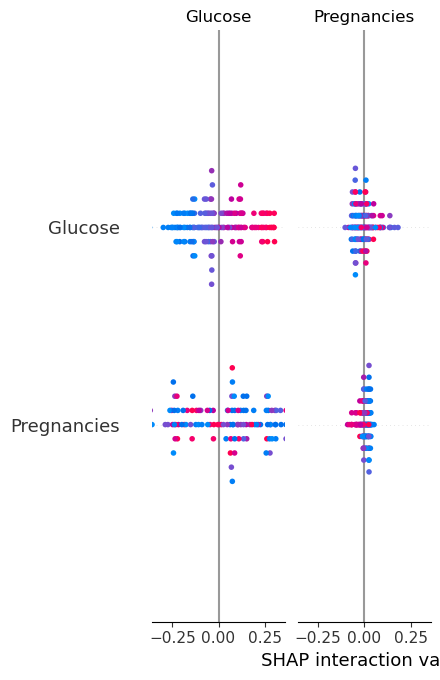

In [ ]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import shap

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.model_selection import cross_val_score

# preprocess_diabetes.py

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import os

DATA_PATH = "diabetes.csv"
ARTIFACT_DIR = "artifacts"
ZERO_AS_NAN_COLS = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
TARGET_COL = 'Outcome'

def load_dataset():
    df = pd.read_csv(DATA_PATH)
    print(f"Dataset loaded: {df.shape}")
    return df

def mark_zeros_as_nan(df, zero_cols):
    df[zero_cols] = df[zero_cols].replace(0, np.nan)
    print("Replaced 0s with NaN in:", zero_cols)
    return df

def impute_missing(df):
    df = df.fillna(df.median())
    print("Missing values imputed with median.")
    return df

def scale_features(X):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    print("Features scaled.")
    return X_scaled, scaler

def preprocess_pipeline(
    zero_cols=ZERO_AS_NAN_COLS,
    target_col=TARGET_COL,
    impute_strategy="median",
    test_size=0.2,
    random_state=42,
    apply_smote_flag=True,
    artifact_dir=ARTIFACT_DIR
):
    df = load_dataset()
    df = mark_zeros_as_nan(df, zero_cols)
    df = impute_missing(df)
    
    X = df.drop(columns=[target_col])
    y = df[target_col]
    
    X_scaled, scaler = scale_features(X)
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=test_size, random_state=random_state)
    
    if apply_smote_flag:
        smote = SMOTE(random_state=random_state)
        X_train, y_train = smote.fit_resample(X_train, y_train)
        print("Applied SMOTE for class balancing.")
    
    os.makedirs(artifact_dir, exist_ok=True)
    np.save(os.path.join(artifact_dir, "X_train.npy"), X_train)
    np.save(os.path.join(artifact_dir, "y_train.npy"), y_train)
    np.save(os.path.join(artifact_dir, "X_test.npy"), X_test)
    np.save(os.path.join(artifact_dir, "y_test.npy"), y_test)
    
    print(f"Preprocessing complete. Files saved in '{artifact_dir}'")
    return X_train, X_test, y_train, y_test


print("🔄 Running preprocessing pipeline...")
X_train, X_test, y_train, y_test = preprocess_pipeline()

print("\n🎯 Training models...")

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Support Vector Machine": SVC(kernel='rbf', probability=True, random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1 Score': round(f1, 4)
    })

    print(f"\n✅ {name} Results:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Convert results to DataFrame
results_df = pd.DataFrame(results)
print("\n📊 Model Comparison:\n", results_df)

# Choose the best model (based on Recall or F1-score)
best_model_name = results_df.sort_values(by="Recall", ascending=False).iloc[0]["Model"]
best_model = models[best_model_name]
print(f"\n🏆 Best model selected based on Recall: {best_model_name}")

# Save the model
joblib.dump(best_model, "artifacts/best_model.joblib")
print("💾 Model saved to artifacts/best_model.joblib")

cv_score = cross_val_score(best_model, X_train, y_train, cv=5, scoring='recall').mean()
print(f"\n🧮 5-Fold Cross Validation Recall Score: {cv_score:.4f}")

print("\n🔍 Generating SHAP explainability plots...")

# Choose explainer based on model type
explainer = shap.Explainer(best_model, X_train)
shap_values = explainer(X_test)

# Summary Plot - shows feature importance
shap.summary_plot(shap_values, X_test, show=False)
plt.title("Feature Importance (SHAP Summary Plot)")
plt.savefig("artifacts/shap_summary.png")
plt.close()

# Bar Plot for mean SHAP values
# -----------------------------
# SHAP Explainability (Fixed)
# -----------------------------
feature_names = ['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']
X_test_df = pd.DataFrame(X_test, columns=feature_names)

explainer = shap.Explainer(best_model, X_test_df)
shap_values = explainer(X_test_df)
shap.summary_plot(shap_values, X_test_df, show=False)
plt.savefig("artifacts/shap_summary.png", bbox_inches="tight")

sample = X_test_df.iloc[0:1]
prediction = best_model.predict(sample)[0]
prob = best_model.predict_proba(sample)[0][1]

print("\n🧪 Sample Prediction:")
print("Input features:\n", sample)
print(f"Predicted Outcome: {'Diabetic' if prediction == 1 else 'Non-Diabetic'} (Probability: {prob:.2f})")

print("\n✅ Training and evaluation complete.")

import streamlit as st


# Load model
model = joblib.load("diabetes_model.pkl")

st.set_page_config(page_title="Medical Diagnosis Helper", layout="wide")

st.title("🩺 Medical Diagnosis Helper (Diabetes Prediction)")
st.markdown("Enter patient details below to check diabetes risk using a trained ML model.")

# Feature inputs
with st.form("input_form"):
    col1, col2, col3 = st.columns(3)
    with col1:
        pregnancies = st.number_input("Pregnancies", 0, 20, 1)
        glucose = st.number_input("Glucose Level", 0, 300, 120)
        blood_pressure = st.number_input("Blood Pressure", 0, 200, 70)
    with col2:
        skin_thickness = st.number_input("Skin Thickness", 0, 100, 20)
        insulin = st.number_input("Insulin Level", 0, 900, 80)
        bmi = st.number_input("BMI", 0.0, 70.0, 25.0)
    with col3:
        dpf = st.number_input("Diabetes Pedigree Function", 0.0, 2.5, 0.5)
        age = st.number_input("Age", 0, 120, 33)

    submitted = st.form_submit_button("🔍 Predict")

if submitted:
    # Prepare input
    data = np.array([[pregnancies, glucose, blood_pressure, skin_thickness,
                      insulin, bmi, dpf, age]])
    feature_names = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
                     'Insulin','BMI','DiabetesPedigreeFunction','Age']
    df = pd.DataFrame(data, columns=feature_names)

    # Predict
    prediction = model.predict(df)[0]
    prob = model.predict_proba(df)[0][1]

    st.subheader("📊 Prediction Result")
    st.write(f"**Predicted Outcome:** {'🩸 Diabetic' if prediction == 1 else '✅ Non-Diabetic'}")
    st.write(f"**Probability of Diabetes:** {prob*100:.2f}%")

    # SHAP Explainability
    st.subheader("🔍 Feature Contribution (Explainable AI)")
    explainer = shap.Explainer(model, df)
    shap_values = explainer(df)

    fig, ax = plt.subplots()
    shap.waterfall_plot(shap_values[0], show=False)
    st.pyplot(fig)



In [ ]:
!pip install shap




   ---------------------------------------- 0.0/548.0 kB ? eta -:--:--
   ------------------- -------------------- 262.1/548.0 kB ? eta -:--:--
   ---------------------------------------- 548.0/548.0 kB 1.7 MB/s eta 0:00:00

   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]

